# Benchmark leaderboard — five challengers vs the LR incumbent

Reads every `outputs/benchmark/*_metrics.json` + `*_holdout_predictions.csv` produced by
`model_catboost / model_xgboost / model_lightgbm / model_rf / model_ebm`, re-fits the
logistic-regression incumbent under the identical protocol (same split, asserted), and
produces:

1. the leaderboard (CV + hold-out, discrimination / calibration / screening),
2. paired DeLong tests of each challenger's hold-out AUC vs LR,
3. overlaid ROC / calibration curves,
4. agreement between models' permutation-importance top-10 sets,
5. a deployment verdict.

*All results are illustrative — synthetic data contains no real patient records (plan §5.1).*


In [1]:
# --- Environment + artefact loading ----------------------------------------------------
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from sklearn.metrics import calibration_curve
except ImportError:
    from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

OUT_DIR = Path("outputs"); BENCH = OUT_DIR / "benchmark"

TARGET = "dementia_status"
NUMERIC_FEATURES = ["age_years", "education_years", "monthly_household_income_usd",
                    "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2", "gds15_score",
                    "fruit_veg_servings_per_day"]
CATEGORICAL_FEATURES = ["province", "residence", "sex", "marital_status",
                        "employment_status", "hiv_status", "smoking_status", "alcohol_use",
                        "physical_activity_level", "social_engagement"]
BINARY_FEATURES = ["lives_alone", "hypertension_dx", "takes_bp_medication", "diabetes_dx",
                   "prior_stroke", "head_injury_history", "family_history_dementia",
                   "hearing_difficulty", "vision_difficulty"]

CHALLENGERS = [("CatBoost", "catboost"), ("XGBoost", "xgboost"), ("LightGBM", "lightgbm"),
               ("Random Forest", "rf"), ("EBM", "ebm")]

all_metrics = {}
all_preds = {}
for name, slug in CHALLENGERS:
    all_metrics[slug] = json.load(open(BENCH / f"{slug}_metrics.json"))
    df_p = pd.read_csv(BENCH / f"{slug}_holdout_predictions.csv")
    all_preds[slug] = df_p
    print(f"loaded {name:14s} hold-out AUC {all_metrics[slug]['holdout']['roc_auc']:.3f}")


loaded CatBoost       hold-out AUC 0.776
loaded XGBoost        hold-out AUC 0.748
loaded LightGBM       hold-out AUC 0.725
loaded Random Forest  hold-out AUC 0.770
loaded EBM            hold-out AUC 0.776


## 0 · LR incumbent re-fit (identical protocol)

In [2]:
# --- LR incumbent, re-fitted under the identical protocol ------------------------------
clean = pd.read_csv(OUT_DIR / "clean_data.csv", keep_default_na=False, na_values=[""])
clean["income_missing"] = clean["monthly_household_income_usd"].isna().astype(int)
X = clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES].copy()
X[BINARY_FEATURES] = X[BINARY_FEATURES].apply(lambda s: pd.to_numeric(s, errors="coerce").astype(float))
X["income_missing"] = clean.loc[X.index, "income_missing"]
y = clean[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
assert (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum())) == (9539, 2385, 767, 192)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]),
     NUMERIC_FEATURES),
    ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                      ("o", OneHotEncoder(drop="first", handle_unknown="ignore"))]),
     CATEGORICAL_FEATURES),
    ("bin", Pipeline([("i", SimpleImputer(strategy="most_frequent"))]), BINARY_FEATURES),
    ("flag", "passthrough", ["income_missing"]),
])
Xtr_p = preprocessor.fit_transform(X_train)
Xte_p = preprocessor.transform(X_test)

lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr_p, y_train)
proba_lr = lr.predict_proba(Xte_p)[:, 1]

# OOF isotonic for LR, same recipe as the challengers.
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_lr = np.zeros(len(Xtr_p))
for tr, va in CV5.split(Xtr_p, y_train):
    m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr_p[tr], y_train.iloc[tr])
    oof_lr[va] = m.predict_proba(Xtr_p[va])[:, 1]
iso_lr = IsotonicRegression(out_of_bounds="clip").fit(oof_lr, y_train)
proba_lr_iso = iso_lr.predict(proba_lr)

def calib_slope_intercept(y_true, p):
    from sklearn.linear_model import LogisticRegression as _LR
    eps = 1e-6
    fit = _LR(C=1e6).fit(np.log((p + eps) / (1 - p + eps)).reshape(-1, 1), y_true)
    return float(fit.coef_[0][0]), float(fit.intercept_[0])

def operating_points(y_true, p):
    fpr, tpr, thr = roc_curve(y_true, p)
    thr_youden = float(thr[np.argmax(tpr - fpr)])
    valid = np.where(tpr >= 0.80)[0]
    thr_screen = float(thr[valid[0]] if len(valid) else thr[-1])
    def ss(t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
        return {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
                "PPV": tp / (tp + fp), "NPV": tn / (tn + fn)}
    return thr_youden, thr_screen, {"Youden J": ss(thr_youden),
                                    "Screening (sens>=0.80)": ss(thr_screen)}

auc_lr = roc_auc_score(y_test, proba_lr)
pr_lr = average_precision_score(y_test, proba_lr)
brier_lr = brier_score_loss(y_test, proba_lr)
brier_lr_iso = brier_score_loss(y_test, proba_lr_iso)
slope_lr, int_lr = calib_slope_intercept(y_test, proba_lr)
slope_lr_iso, int_lr_iso = calib_slope_intercept(y_test, proba_lr_iso)
thr_y_lr, thr_s_lr, pts_lr = operating_points(y_test, proba_lr)

# 5-fold CV AUC for LR on the same folds the challengers used.
cv_aucs = []
for tr, va in CV5.split(Xtr_p, y_train):
    m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr_p[tr], y_train.iloc[tr])
    cv_aucs.append(roc_auc_score(y_train.iloc[va], m.predict_proba(Xtr_p[va])[:, 1]))
cv_auc_lr = (float(np.mean(cv_aucs)), float(np.std(cv_aucs)))

all_metrics["lr"] = {"model": "Logistic Regression",
    "cv_tuned": {"roc_auc": {"mean": cv_auc_lr[0], "sd": cv_auc_lr[1]}},
    "holdout": {"roc_auc": float(auc_lr), "pr_auc": float(pr_lr),
                "brier_raw": float(brier_lr), "brier_isotonic": float(brier_lr_iso),
                "calib_slope_raw": slope_lr, "calib_intercept_raw": int_lr,
                "calib_slope_isotonic": slope_lr_iso,
                "calib_intercept_isotonic": int_lr_iso,
                "youden": pts_lr["Youden J"], "screening": pts_lr["Screening (sens>=0.80)"]}}
all_preds["lr"] = pd.DataFrame({"y_true": y_test.values, "proba_raw": proba_lr,
                                "proba_isotonic": proba_lr_iso,
                                "sex": X_test["sex"].values,
                                "residence": X_test["residence"].values})
all_preds["lr"].to_csv(BENCH / "lr_holdout_predictions.csv", index=False)
print(f"LR incumbent re-fit: hold-out AUC {auc_lr:.3f} (modelx reported 0.771) | "
      f"CV AUC {cv_auc_lr[0]:.3f} +/- {cv_auc_lr[1]:.3f} (modelx: 0.785 +/- 0.011)")


LR incumbent re-fit: hold-out AUC 0.771 (modelx reported 0.771) | CV AUC 0.785 +/- 0.011 (modelx: 0.785 +/- 0.011)


## 1 · Leaderboard

In [3]:
# --- Leaderboard ------------------------------------------------------------------------
ROWS = [("Logistic Regression", "lr")] + list(CHALLENGERS)
def _cv_auc(met):
    """CV AUCs arrive as {metric: [mean, sd]} from JSON; handle dict or list."""
    v = met.get("cv_tuned", {}).get("roc_auc")
    if isinstance(v, dict):
        return v["mean"]
    if isinstance(v, (list, tuple)):
        return v[0]
    return np.nan

rows = []
lr_auc = all_metrics["lr"]["holdout"]["roc_auc"]
for name, slug in ROWS:
    h = all_metrics[slug]["holdout"]
    rows.append({
        "Model": name,
        "CV AUC": _cv_auc(all_metrics[slug]),
        "Hold-out AUC": h["roc_auc"],
        "d AUC vs LR": h["roc_auc"] - lr_auc,
        "PR-AUC": h["pr_auc"],
        "Brier raw": h["brier_raw"],
        "Brier iso": h["brier_isotonic"],
        "Slope raw": h["calib_slope_raw"],
        "Slope iso": h["calib_slope_isotonic"],
        "Youden sens": h["youden"]["sensitivity"],
        "Youden spec": h["youden"]["specificity"],
        "Screen sens": h["screening"]["sensitivity"],
        "Screen spec": h["screening"]["specificity"],
        "Screen NPV": h["screening"]["NPV"],
    })
leaderboard = (pd.DataFrame(rows)
               .sort_values("Hold-out AUC", ascending=False)
               .reset_index(drop=True))
display(leaderboard.round(4))
leaderboard.round(5).to_csv(BENCH / "leaderboard.csv", index=False)
print("Saved outputs/benchmark/leaderboard.csv")


,Model,CV AUC,Hold-out AUC,d AUC vs LR,PR-AUC,Brier raw,Brier iso,Slope raw,Slope iso,Youden sens,Youden spec,Screen sens,Screen spec,Screen NPV
0,CatBoost,0.7873,0.7763,0.0054,0.3390,0.0633,0.0635,0.9510,0.8883,0.6719,0.7761,0.8021,0.5385,0.9688
1,EBM,0.7895,0.7756,0.0047,0.3453,0.0631,0.0638,1.0446,0.8855,0.5938,0.8472,0.8021,0.5390,0.9689
2,Logistic Regression,0.7845,0.7709,0.0000,0.3367,0.0634,0.0636,0.9139,0.9220,0.6198,0.8103,0.8021,0.5107,0.9672
3,Random Forest,0.7814,0.7705,-0.0004,0.3491,0.0644,0.0634,1.2261,0.9275,0.6562,0.7820,0.8021,0.5609,0.9700
4,XGBoost,0.7502,0.7480,-0.0228,0.2800,0.0687,0.0664,0.6030,0.9445,0.6250,0.7638,0.8021,0.5253,0.9681
5,LightGBM,0.7417,0.7246,-0.0463,0.2601,0.0708,0.0680,0.3892,0.9183,0.6875,0.6516,0.8021,0.4560,0.9634


Saved outputs/benchmark/leaderboard.csv


## 2 · Paired DeLong tests vs LR

A point-estimate AUC gap is not evidence — the hold-out AUCs are correlated (same 2,385 rows), so we use the paired DeLong test with Bonferroni correction for the 5 challenger comparisons.

In [4]:
# --- Paired DeLong tests: each challenger AUC vs LR, same hold-out samples --------------
def _midrank(x):
    J = np.argsort(x, kind="mergesort"); Z = x[J]; n = len(x); T = np.zeros(n)
    i = 0
    while i < n:
        j = i
        while j < n and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1          # average 1-based rank of the tie block
        i = j
    out = np.empty(n); out[J] = T
    return out

def delong_vs_reference(y_true, p_ref, p_chal):
    """Paired DeLong test (DeLong et al. 1988) for two correlated ROC-AUCs."""
    y = np.asarray(y_true); p1 = np.asarray(p_ref); p2 = np.asarray(p_chal)
    m = int((y == 1).sum()); n = int((y == 0).sum())
    def components(p):
        pos, neg = p[y == 1], p[y == 0]
        tz = _midrank(np.concatenate([pos, neg]))
        tx, ty = _midrank(pos), _midrank(neg)
        auc = (tz[:m].sum() - m * (m + 1) / 2) / (m * n)
        return auc, (tz[:m] - tx) / n, (tz[m:] - ty) / m
    auc1, v10_1, v01_1 = components(p1)
    auc2, v10_2, v01_2 = components(p2)
    s10, s01 = v10_1 - v10_2, v01_1 - v01_2
    var = s10.var(ddof=1) / m + s01.var(ddof=1) / n
    z = (auc2 - auc1) / np.sqrt(var)
    pval = 2 * norm.sf(abs(z))
    return auc1, auc2, float(z), float(pval)

y_hold = all_preds["lr"]["y_true"].values
p_lr = all_preds["lr"]["proba_raw"].values
dl_rows = []
for name, slug in CHALLENGERS:
    p_m = all_preds[slug]["proba_raw"].values
    a_lr, a_m, z, pval = delong_vs_reference(y_hold, p_lr, p_m)
    dl_rows.append({"Model": name, "AUC": a_m, "AUC (LR)": a_lr, "d AUC": a_m - a_lr,
                    "z": z, "p (uncorrected)": pval,
                    "p (Bonferroni x5)": min(1.0, pval * 5),
                    "sig at 0.05": "YES" if pval * 5 < 0.05 else "no"})
dl_tab = pd.DataFrame(dl_rows)
display(dl_tab.round(4))
dl_tab.round(5).to_csv(BENCH / "delong_vs_lr.csv", index=False)
print("Delta AUC is significant only where the Bonferroni-adjusted p < 0.05 "
      "(5 comparisons, family-wise alpha = 0.05).")


,Model,AUC,AUC (LR),d AUC,z,p (uncorrected),p (Bonferroni x5),sig at 0.05
0,CatBoost,0.7763,0.7709,0.0054,0.8449,0.3982,1.0000,no
1,XGBoost,0.7480,0.7709,-0.0228,-1.8666,0.0620,0.3098,no
2,LightGBM,0.7246,0.7709,-0.0463,-3.2584,0.0011,0.0056,YES
3,Random Forest,0.7705,0.7709,-0.0004,-0.0447,0.9644,1.0000,no
4,EBM,0.7756,0.7709,0.0047,1.0856,0.2776,1.0000,no


Delta AUC is significant only where the Bonferroni-adjusted p < 0.05 (5 comparisons, family-wise alpha = 0.05).


## 3 · Overlaid ROC and calibration curves

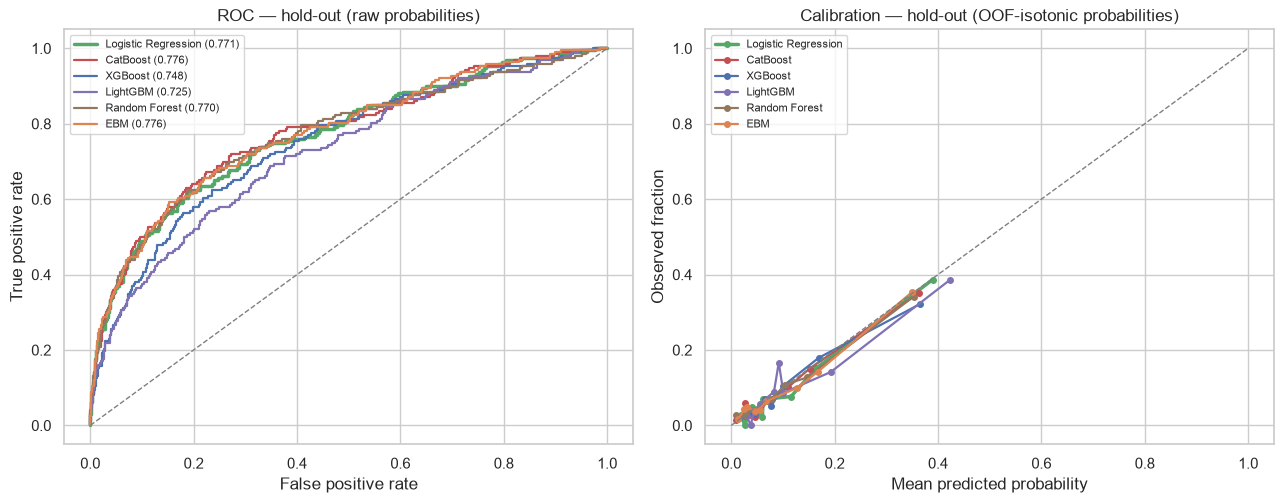

In [5]:
# --- Overlaid curves: ROC (raw) and calibration (isotonic) -----------------------------
COLORS = {"lr": "#55a868", "catboost": "#c44e52", "xgboost": "#4c72b0",
          "lightgbm": "#8172b3", "rf": "#937860", "ebm": "#dd8452"}
LABELS = {"lr": "Logistic Regression", **{s: n for n, s in CHALLENGERS}}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for slug in ["lr"] + [s for _, s in CHALLENGERS]:
    yv = all_preds[slug]["y_true"].values
    fpr, tpr, _ = roc_curve(yv, all_preds[slug]["proba_raw"].values)
    auc_v = roc_auc_score(yv, all_preds[slug]["proba_raw"].values)
    lw = 2.5 if slug == "lr" else 1.6
    axes[0].plot(fpr, tpr, lw=lw, color=COLORS[slug],
                 label=f"{LABELS[slug]} ({auc_v:.3f})")
    frac, mean_p = calibration_curve(yv, all_preds[slug]["proba_isotonic"].values,
                                     n_bins=10, strategy="quantile")
    axes[1].plot(mean_p, frac, "o-", ms=4, lw=lw, color=COLORS[slug], label=LABELS[slug])
axes[0].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — hold-out (raw probabilities)"); axes[0].legend(fontsize=8)
axes[1].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[1].set_xlabel("Mean predicted probability"); axes[1].set_ylabel("Observed fraction")
axes[1].set_title("Calibration — hold-out (OOF-isotonic probabilities)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4 · Feature-importance agreement across models

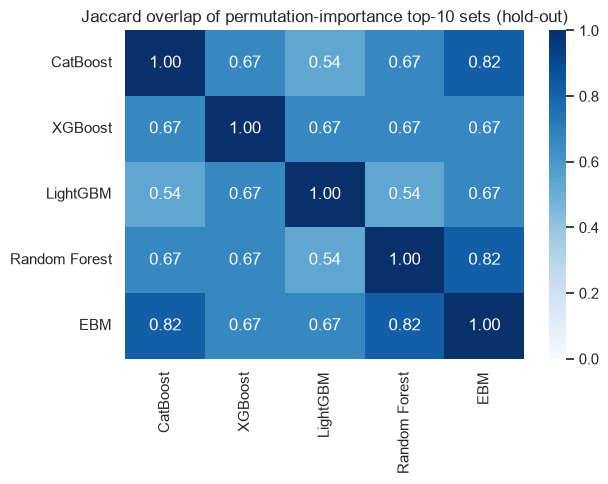

,CatBoost,XGBoost,LightGBM,Random Forest,EBM
age_years,True,True,True,True,True
diabetes_dx,False,False,True,True,True
diastolic_bp_mmhg,True,False,False,False,False
education_years,True,True,False,True,True
family_history_dementia,True,True,True,True,True
gds15_score,True,True,True,True,True
hearing_difficulty,True,False,False,True,True
hypertension_dx,True,True,True,True,True
lives_alone,True,True,True,False,True
prior_stroke,True,True,True,True,True


In [6]:
# --- Do the models agree on what matters? Jaccard overlap of top-10 features -----------
top10 = {slug: {r["feature"] for r in all_metrics[slug]["perm_importance_top15"][:10]}
         for slug in [s for _, s in CHALLENGERS]}
slugs = list(top10)
jac = pd.DataFrame(index=[LABELS[s] for s in slugs], columns=[LABELS[s] for s in slugs], dtype=float)
for a in slugs:
    for b in slugs:
        jac.loc[LABELS[a], LABELS[b]] = len(top10[a] & top10[b]) / len(top10[a] | top10[b])
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(jac.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Jaccard overlap of permutation-importance top-10 sets (hold-out)")
plt.tight_layout(); plt.show()

union10 = sorted(set().union(*top10.values()))
present = pd.DataFrame({LABELS[s]: [f in top10[s] for f in union10] for s in slugs}, index=union10)
display(present)


## 5 · Verdict

In [7]:
# --- Verdict ---------------------------------------------------------------------------
best_row = leaderboard.iloc[0]
n_sig = int((dl_tab["p (Bonferroni x5)"] < 0.05).sum())
best_cal = leaderboard.loc[leaderboard["Brier iso"].idxmin()]

print("=" * 92)
print("BENCHMARK VERDICT (hold-out n=2,385, 192 events — synthetic data, illustrative)")
print("=" * 92)
print(f"1. Best discrimination : {best_row['Model']}  "
      f"(hold-out AUC {best_row['Hold-out AUC']:.3f}, d {best_row['d AUC vs LR']:+.3f} vs LR)")
print(f"2. DeLong vs LR        : {n_sig} of {len(CHALLENGERS)} challengers significantly "
      f"different from LR after Bonferroni x5")
sig = dl_tab[dl_tab["p (Bonferroni x5)"] < 0.05]
if len(sig):
    for _, r in sig.iterrows():
        print(f"     - {r['Model']}: d AUC {r['d AUC']:+.3f}, "
              f"adjusted p = {r['p (Bonferroni x5)']:.4f}")
else:
    print("     - none: all challengers are statistically indistinguishable from LR on this data")
print(f"3. Best calibrated     : {best_cal['Model']} (isotonic Brier {best_cal['Brier iso']:.4f})")
print(f"4. Screening NPV range : "
      f"{leaderboard['Screen NPV'].min():.3f} - {leaderboard['Screen NPV'].max():.3f} "
      f"at sens ~0.80 (LR: 0.967)")
print()
print("Reading: if no challenger clears LR by a significant margin, the incumbent LR stays")
print("the deployment candidate (interpretable, calibrated, already thresholded) unless a")
print("model wins on BOTH discrimination and calibration. EBM additionally preserves exact")
print("shape-function interpretability, making it the strongest glass-box alternative.")
print("=" * 92)


BENCHMARK VERDICT (hold-out n=2,385, 192 events — synthetic data, illustrative)
1. Best discrimination : CatBoost  (hold-out AUC 0.776, d +0.005 vs LR)
2. DeLong vs LR        : 1 of 5 challengers significantly different from LR after Bonferroni x5
     - LightGBM: d AUC -0.046, adjusted p = 0.0056
3. Best calibrated     : Random Forest (isotonic Brier 0.0634)
4. Screening NPV range : 0.963 - 0.970 at sens ~0.80 (LR: 0.967)

Reading: if no challenger clears LR by a significant margin, the incumbent LR stays
the deployment candidate (interpretable, calibrated, already thresholded) unless a
model wins on BOTH discrimination and calibration. EBM additionally preserves exact
shape-function interpretability, making it the strongest glass-box alternative.
